Available columns:
['Potential, E (mV)', 'Current density, log|J|  (µA/cm2)', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Antilog']
Using columns: Potential, E (mV) | Current density, log|J|  (µA/cm2)


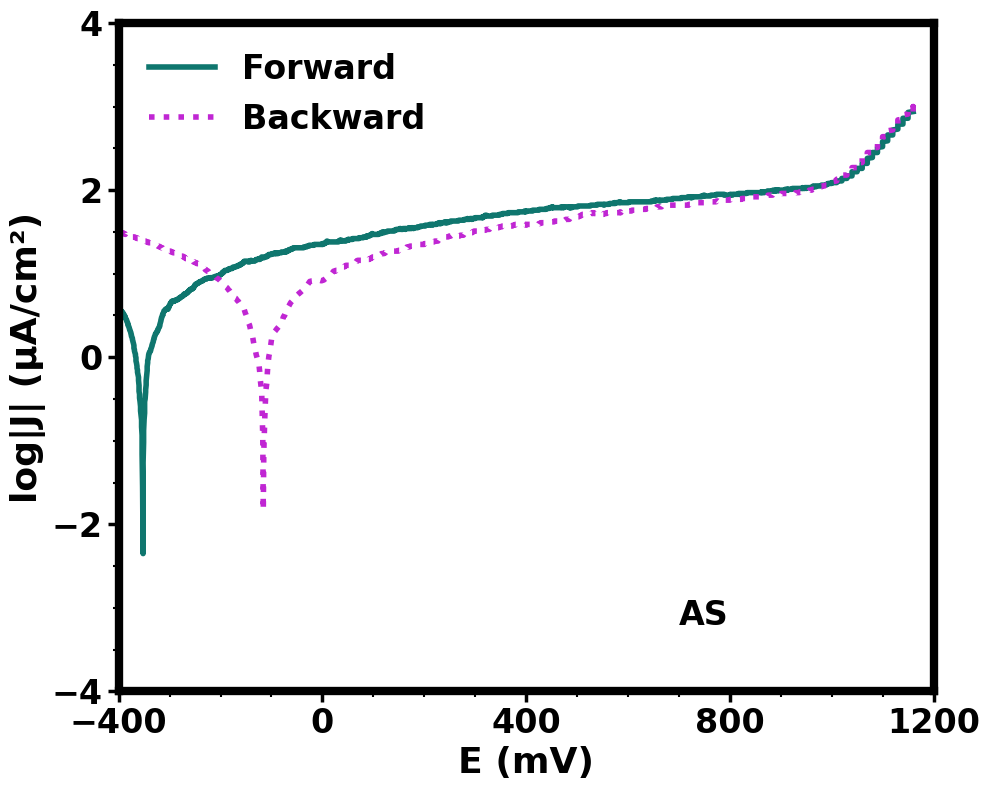

Plot saved as: AS_CPP_plot.png
Plot saved as: AS_CPP_plot.svg


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- File names ---
csv_name = 'AS_CPP.csv'
out_png = 'AS_CPP_plot.png'
out_svg = 'AS_CPP_plot.svg'

# --- Read the CSV ---
df = pd.read_csv(csv_name)

# Clean column names
df.columns = [str(c).strip() for c in df.columns]

# Print available columns for checking
print("Available columns:")
print(df.columns.tolist())

# --- Actual columns in your uploaded CSV ---
pot_col = 'Potential, E (mV)'
curr_col = 'Current density, log|J|  (µA/cm2)'

# If exact names are not found, fall back to first two non-empty columns
if pot_col not in df.columns or curr_col not in df.columns:
    valid_cols = [c for c in df.columns if not str(c).startswith('Unnamed')]
    if len(valid_cols) >= 2:
        pot_col = valid_cols[0]
        curr_col = valid_cols[1]
    else:
        raise KeyError("Could not identify the required potential/current columns.")

print(f"Using columns: {pot_col} | {curr_col}")

# Keep only needed columns
df = df[[pot_col, curr_col]].copy()

# Convert to numeric
df[pot_col] = pd.to_numeric(df[pot_col], errors='coerce')
df[curr_col] = pd.to_numeric(df[curr_col], errors='coerce')
df = df.dropna().reset_index(drop=True)

# --- Remove the first stray point if it causes an artificial jump ---
if len(df) > 1 and abs(df.loc[1, pot_col] - df.loc[0, pot_col]) > 100:
    df = df.iloc[1:].reset_index(drop=True)

# --- Split forward / reverse scan using the maximum potential point ---
split_idx = df[pot_col].idxmax()
forward = df.iloc[:split_idx + 1]
reverse = df.iloc[split_idx + 1:]

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 8))

# Forward scan
ax.plot(
    forward[pot_col],
    forward[curr_col],
    label='Forward',
    linestyle='-',
    linewidth=4,
    color='#0F766E'   # dark teal
)

# Reverse scan
if not reverse.empty:
    ax.plot(
        reverse[pot_col],
        reverse[curr_col],
        label='Backward',
        linestyle=':',
        linewidth=4,
        color='#C026D3'   # deep magenta
    )

# Labels & limits
ax.set_xlabel('E (mV)', fontsize=26, fontweight='bold')
ax.set_ylabel('log|J| (µA/cm²)', fontsize=26, fontweight='bold')
ax.set_xlim(-400, 1200)
ax.set_ylim(-4, 4)

# Major ticks
ax.set_xticks([-400, 0, 400, 800, 1200])
ax.set_yticks([-4, -2, 0, 2, 4])

# Tick styling
ax.tick_params(axis='both', which='major', direction='out', length=8, width=2.5, labelsize=24)
ax.tick_params(axis='both', which='minor', direction='out', length=4, width=1.5)

for lbl in ax.get_xticklabels() + ax.get_yticklabels():
    lbl.set_fontweight('bold')

# Minor ticks
ax.xaxis.set_minor_locator(ticker.MultipleLocator(100))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))

# Spine thickness
for spine in ax.spines.values():
    spine.set_linewidth(6)

# Legend
leg = ax.legend(fontsize=24, frameon=False)
for line in leg.get_lines():
    line.set_linewidth(4)
for text in leg.get_texts():
    text.set_fontweight('bold')

# Annotation
ax.text(
    700, -3.2, 'AS',
    fontsize=24,
    fontweight='bold'
)

plt.grid(False)
plt.tight_layout()

# Save both PNG and SVG
plt.savefig(out_png, dpi=600, bbox_inches='tight')
plt.savefig(out_svg, bbox_inches='tight')

plt.show()

print(f"Plot saved as: {out_png}")
print(f"Plot saved as: {out_svg}")

Available columns:
['Potential, E, mV', 'Current density, log|J|, µA/cm2']
Using columns: Potential, E, mV | Current density, log|J|, µA/cm2


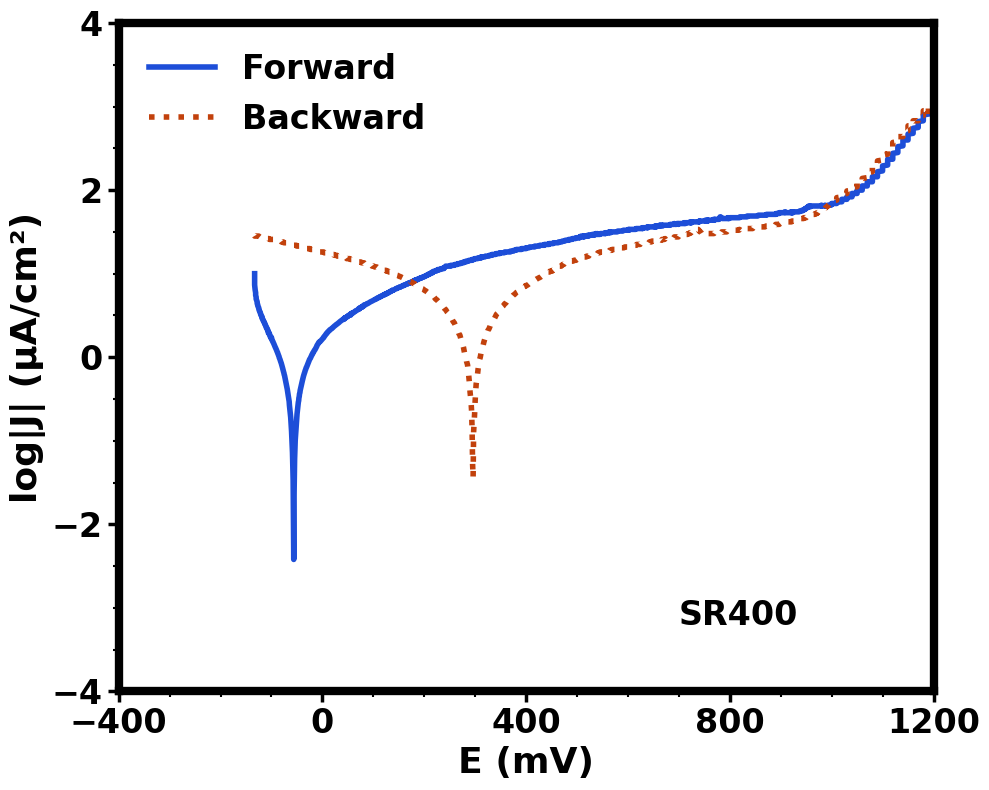

Plot saved as: SR400_CPP_plot.png
Plot saved as: SR400_CPP_plot.svg


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- File names ---
csv_name = 'SR400_CPP.csv'
out_png = 'SR400_CPP_plot.png'
out_svg = 'SR400_CPP_plot.svg'

# --- Read the CSV ---
df = pd.read_csv(csv_name)

# Clean column names
df.columns = [str(c).strip() for c in df.columns]

# Print available columns for checking
print("Available columns:")
print(df.columns.tolist())

# --- Actual columns in your uploaded SR400_CPP.csv ---
pot_col = 'Potential, E, mV'
curr_col = 'Current density, log|J|, µA/cm2'

# Check that columns exist
if pot_col not in df.columns or curr_col not in df.columns:
    valid_cols = [c for c in df.columns if not str(c).startswith('Unnamed')]
    if len(valid_cols) >= 2:
        pot_col = valid_cols[0]
        curr_col = valid_cols[1]
    else:
        raise KeyError("Could not identify the required potential/current columns.")

print(f"Using columns: {pot_col} | {curr_col}")

# Keep only needed columns
df = df[[pot_col, curr_col]].copy()

# Convert to numeric
df[pot_col] = pd.to_numeric(df[pot_col], errors='coerce')
df[curr_col] = pd.to_numeric(df[curr_col], errors='coerce')
df = df.dropna().reset_index(drop=True)

# --- Remove the first stray point if it causes an artificial jump ---
if len(df) > 1 and abs(df.loc[1, pot_col] - df.loc[0, pot_col]) > 100:
    df = df.iloc[1:].reset_index(drop=True)

# --- Split forward / reverse scan using the maximum potential point ---
split_idx = df[pot_col].idxmax()
forward = df.iloc[:split_idx + 1]
reverse = df.iloc[split_idx + 1:]

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 8))

# Forward scan
ax.plot(
    forward[pot_col],
    forward[curr_col],
    label='Forward',
    linestyle='-',
    linewidth=4,
    color='#1D4ED8'   # deep royal blue
)

# Reverse scan
if not reverse.empty:
    ax.plot(
        reverse[pot_col],
        reverse[curr_col],
        label='Backward',
        linestyle=':',
        linewidth=4,
        color='#C2410C'   # burnt orange
    )

# Labels & limits
ax.set_xlabel('E (mV)', fontsize=26, fontweight='bold')
ax.set_ylabel('log|J| (µA/cm²)', fontsize=26, fontweight='bold')
ax.set_xlim(-400, 1200)
ax.set_ylim(-4, 4)

# Major ticks
ax.set_xticks([-400, 0, 400, 800, 1200])
ax.set_yticks([-4, -2, 0, 2, 4])

# Tick styling
ax.tick_params(axis='both', which='major', direction='out', length=8, width=2.5, labelsize=24)
ax.tick_params(axis='both', which='minor', direction='out', length=4, width=1.5)

for lbl in ax.get_xticklabels() + ax.get_yticklabels():
    lbl.set_fontweight('bold')

# Minor ticks
ax.xaxis.set_minor_locator(ticker.MultipleLocator(100))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))

# Spine thickness
for spine in ax.spines.values():
    spine.set_linewidth(6)

# Legend
leg = ax.legend(fontsize=24, frameon=False)
for line in leg.get_lines():
    line.set_linewidth(4)
for text in leg.get_texts():
    text.set_fontweight('bold')

# Annotation
ax.text(
    700, -3.2, 'SR400',
    fontsize=24,
    fontweight='bold'
)

plt.grid(False)
plt.tight_layout()

# Save both PNG and SVG
plt.savefig(out_png, dpi=600, bbox_inches='tight')
plt.savefig(out_svg, bbox_inches='tight')

plt.show()

print(f"Plot saved as: {out_png}")
print(f"Plot saved as: {out_svg}")

Available columns:
['mV', 'log |µA/cm2|']
Using columns: mV | log |µA/cm2|


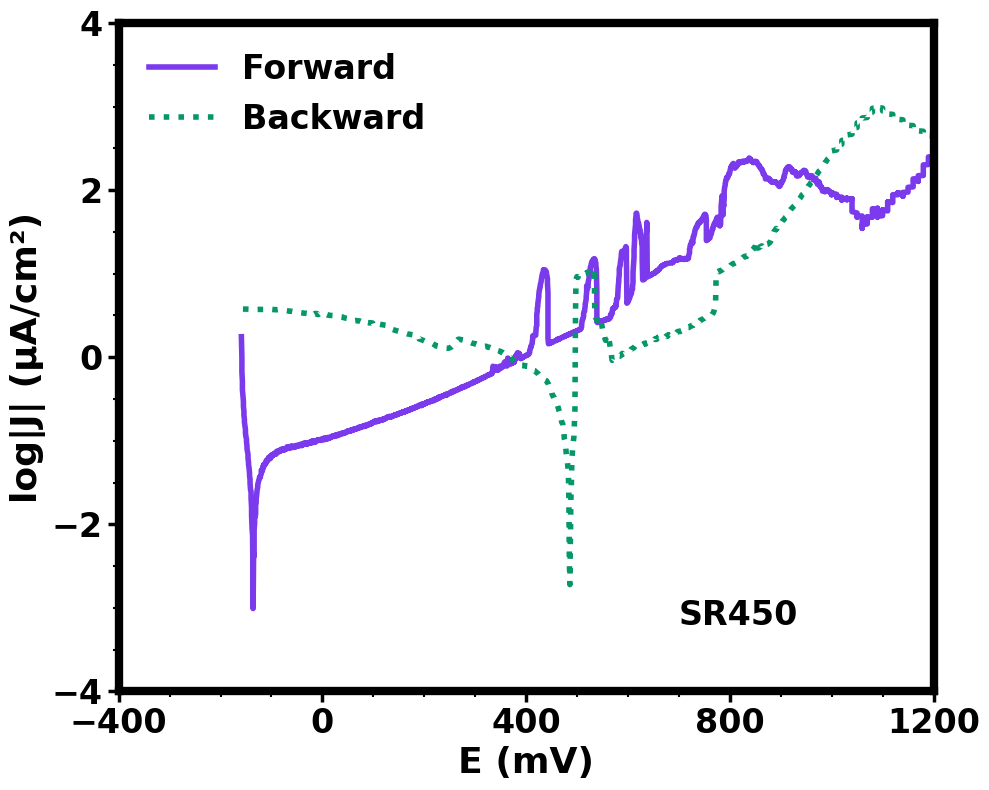

Plot saved as: SR450_CPP_plot.png
Plot saved as: SR450_CPP_plot.svg


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- File names ---
csv_name = 'SR450_CPP_new.csv'
out_png = 'SR450_CPP_plot.png'
out_svg = 'SR450_CPP_plot.svg'

# --- Read the CSV ---
df = pd.read_csv(csv_name)

# Clean column names
df.columns = [str(c).strip() for c in df.columns]

# Print available columns for checking
print('Available columns:')
print(df.columns.tolist())

# --- Expected columns (fallback logic below handles variations) ---
pot_col = 'Potential, E (mV)'
curr_col = 'Current density, log|J|  (µA/cm2)'

# Fallback to first two non-empty columns if exact names differ
if pot_col not in df.columns or curr_col not in df.columns:
    valid_cols = [c for c in df.columns if not str(c).startswith('Unnamed')]
    if len(valid_cols) >= 2:
        pot_col = valid_cols[0]
        curr_col = valid_cols[1]
    else:
        raise KeyError('Could not identify the required potential/current columns.')

print(f'Using columns: {pot_col} | {curr_col}')

# Keep only needed columns
df = df[[pot_col, curr_col]].copy()

# Convert to numeric
df[pot_col] = pd.to_numeric(df[pot_col], errors='coerce')
df[curr_col] = pd.to_numeric(df[curr_col], errors='coerce')
df = df.dropna().reset_index(drop=True)

# --- Remove first stray point if it causes an artificial jump ---
if len(df) > 1 and abs(df.loc[1, pot_col] - df.loc[0, pot_col]) > 100:
    df = df.iloc[1:].reset_index(drop=True)

# --- Split forward / reverse scan using maximum potential ---
split_idx = df[pot_col].idxmax()
forward = df.iloc[:split_idx + 1]
reverse = df.iloc[split_idx + 1:]

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 8))

# Forward scan
ax.plot(
    forward[pot_col],
    forward[curr_col],
    label='Forward',
    linestyle='-',
    linewidth=4,
    color='#7C3AED'   # vivid violet
)

# Reverse scan
if not reverse.empty:
    ax.plot(
        reverse[pot_col],
        reverse[curr_col],
        label='Backward',
        linestyle=':',
        linewidth=4,
        color='#059669'   # emerald green
    )

# Labels & limits
ax.set_xlabel('E (mV)', fontsize=26, fontweight='bold')
ax.set_ylabel('log|J| (µA/cm²)', fontsize=26, fontweight='bold')
ax.set_xlim(-400, 1200)
ax.set_ylim(-4, 4)

# Major ticks
ax.set_xticks([-400, 0, 400, 800, 1200])
ax.set_yticks([-4, -2, 0, 2, 4])

# Tick styling
ax.tick_params(axis='both', which='major', direction='out', length=8, width=2.5, labelsize=24)
ax.tick_params(axis='both', which='minor', direction='out', length=4, width=1.5)

for lbl in ax.get_xticklabels() + ax.get_yticklabels():
    lbl.set_fontweight('bold')

# Minor ticks
ax.xaxis.set_minor_locator(ticker.MultipleLocator(100))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))

# Spine thickness
for spine in ax.spines.values():
    spine.set_linewidth(6)

# Legend
leg = ax.legend(fontsize=24, frameon=False)
for line in leg.get_lines():
    line.set_linewidth(4)
for text in leg.get_texts():
    text.set_fontweight('bold')

# Annotation
ax.text(
    700, -3.2, 'SR450',
    fontsize=24,
    fontweight='bold'
)

plt.grid(False)
plt.tight_layout()

# Save both PNG and SVG
plt.savefig(out_png, dpi=600, bbox_inches='tight')
plt.savefig(out_svg, bbox_inches='tight')

plt.show()

print(f'Plot saved as: {out_png}')
print(f'Plot saved as: {out_svg}')

Available columns:
['Ewe/mV', 'log (|J/µA/cm2|)']
Using columns: Ewe/mV | log (|J/µA/cm2|)


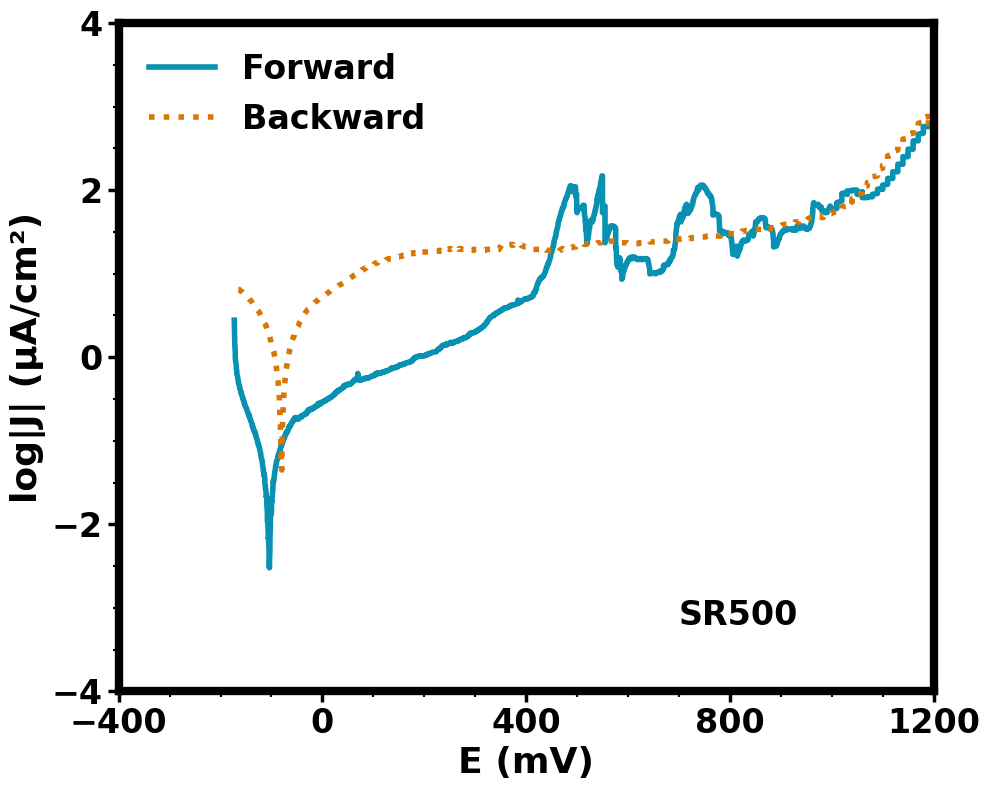

Plot saved as: SR500_CPP_plot.png
Plot saved as: SR500_CPP_plot.svg


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- File names ---
csv_name = 'SR500 _CPP.csv'
out_png = 'SR500_CPP_plot.png'
out_svg = 'SR500_CPP_plot.svg'

# --- Read the CSV ---
df = pd.read_csv(csv_name)

# Clean column names
df.columns = [str(c).strip() for c in df.columns]

# Print available columns
print("Available columns:")
print(df.columns.tolist())

# --- Expected columns for this uploaded CSV ---
pot_col = 'mV'
curr_col = 'log |µA/cm2|'

# Check that columns exist; otherwise fall back to first two non-empty columns
if pot_col not in df.columns or curr_col not in df.columns:
    valid_cols = [c for c in df.columns if not str(c).startswith('Unnamed')]
    if len(valid_cols) >= 2:
        pot_col = valid_cols[0]
        curr_col = valid_cols[1]
    else:
        raise KeyError("Could not identify the required potential/current columns.")

print(f"Using columns: {pot_col} | {curr_col}")

# Keep only needed columns
df = df[[pot_col, curr_col]].copy()

# Convert to numeric
df[pot_col] = pd.to_numeric(df[pot_col], errors='coerce')
df[curr_col] = pd.to_numeric(df[curr_col], errors='coerce')
df = df.dropna().reset_index(drop=True)

# --- Remove the first stray point if it causes an artificial jump ---
if len(df) > 1 and abs(df.loc[1, pot_col] - df.loc[0, pot_col]) > 100:
    df = df.iloc[1:].reset_index(drop=True)

# --- Split forward / reverse scan using the maximum potential point ---
split_idx = df[pot_col].idxmax()
forward = df.iloc[:split_idx + 1]
reverse = df.iloc[split_idx + 1:]

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 8))

# Forward scan
ax.plot(
    forward[pot_col],
    forward[curr_col],
    label='Forward',
    linestyle='-',
    linewidth=4,
    color='#0891B2'   # cyan blue
)

# Reverse scan
if not reverse.empty:
    ax.plot(
        reverse[pot_col],
        reverse[curr_col],
        label='Backward',
        linestyle=':',
        linewidth=4,
        color='#D97706'   # amber orange
    )

# Labels & limits
ax.set_xlabel('E (mV)', fontsize=26, fontweight='bold')
ax.set_ylabel('log|J| (µA/cm²)', fontsize=26, fontweight='bold')
ax.set_xlim(-400, 1200)
ax.set_ylim(-4, 4)

# Major ticks
ax.set_xticks([-400, 0, 400, 800, 1200])
ax.set_yticks([-4, -2, 0, 2, 4])

# Tick styling
ax.tick_params(axis='both', which='major', direction='out', length=8, width=2.5, labelsize=24)
ax.tick_params(axis='both', which='minor', direction='out', length=4, width=1.5)

for lbl in ax.get_xticklabels() + ax.get_yticklabels():
    lbl.set_fontweight('bold')

# Minor ticks
ax.xaxis.set_minor_locator(ticker.MultipleLocator(100))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))

# Spine thickness
for spine in ax.spines.values():
    spine.set_linewidth(6)

# Legend
leg = ax.legend(fontsize=24, frameon=False)
for line in leg.get_lines():
    line.set_linewidth(4)
for text in leg.get_texts():
    text.set_fontweight('bold')

# Annotation
ax.text(
    700, -3.2, 'SR500',
    fontsize=24,
    fontweight='bold'
)

plt.grid(False)
plt.tight_layout()

# Save both PNG and SVG
plt.savefig(out_png, dpi=600, bbox_inches='tight')
plt.savefig(out_svg, bbox_inches='tight')

plt.show()

print(f"Plot saved as: {out_png}")
print(f"Plot saved as: {out_svg}")



Available columns:
['Ewe/mV', 'log (|J/µA/cm2|)']
Using columns: Ewe/mV | log (|J/µA/cm2|)


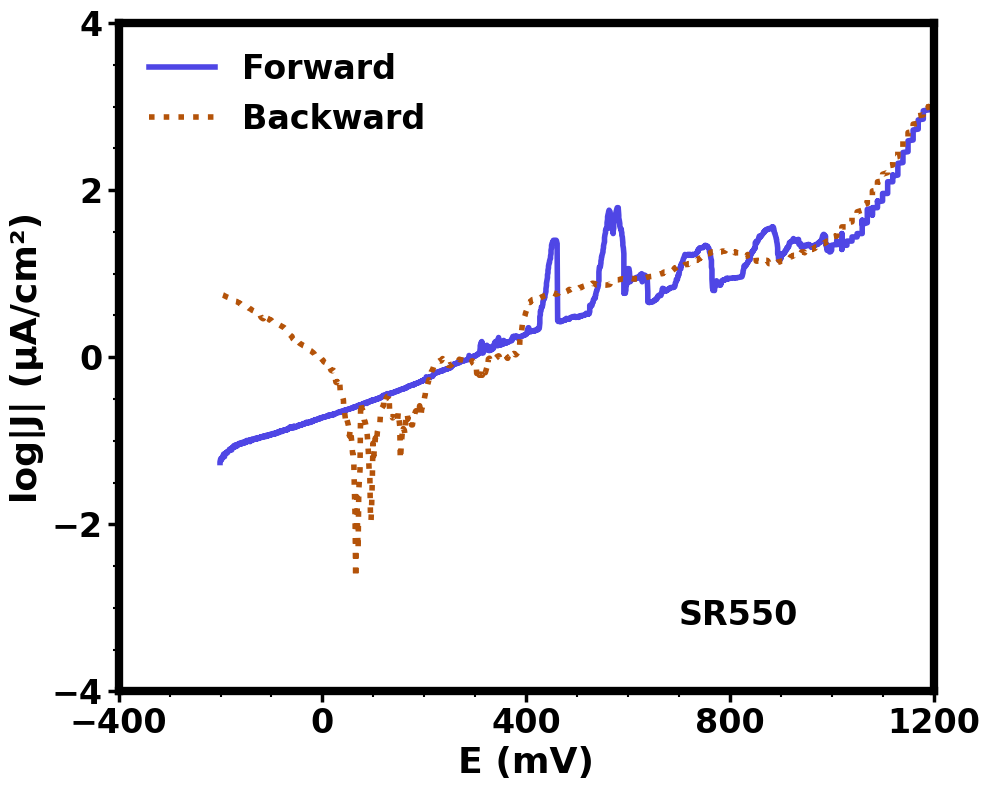

Plot saved as: SR550_CPP_plot.png
Plot saved as: SR550_CPP_plot.svg


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- File names ---
csv_name = 'SR550_CPP.csv'
out_png = 'SR550_CPP_plot.png'
out_svg = 'SR550_CPP_plot.svg'

# --- Read the CSV ---
df = pd.read_csv(csv_name)

# Clean column names
df.columns = [str(c).strip() for c in df.columns]

# Print available columns
print("Available columns:")
print(df.columns.tolist())

# --- Actual columns in your uploaded CSV ---
pot_col = 'Ewe/mV'
curr_col = 'log (|J/µA/cm2|)'

# Check that columns exist
if pot_col not in df.columns or curr_col not in df.columns:
    valid_cols = [c for c in df.columns if not str(c).startswith('Unnamed')]
    if len(valid_cols) >= 2:
        pot_col = valid_cols[0]
        curr_col = valid_cols[1]
    else:
        raise KeyError("Could not identify the required potential/current columns.")

print(f"Using columns: {pot_col} | {curr_col}")

# Keep only needed columns
df = df[[pot_col, curr_col]].copy()

# Convert to numeric
df[pot_col] = pd.to_numeric(df[pot_col], errors='coerce')
df[curr_col] = pd.to_numeric(df[curr_col], errors='coerce')
df = df.dropna().reset_index(drop=True)

# --- Remove the first stray point if it causes an artificial jump ---
if len(df) > 1 and abs(df.loc[1, pot_col] - df.loc[0, pot_col]) > 100:
    df = df.iloc[1:].reset_index(drop=True)

# --- Split forward / reverse scan using the maximum potential point ---
split_idx = df[pot_col].idxmax()
forward = df.iloc[:split_idx + 1]
reverse = df.iloc[split_idx + 1:]

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 8))

# Forward scan
ax.plot(
    forward[pot_col],
    forward[curr_col],
    label='Forward',
    linestyle='-',
    linewidth=4,
    color='#4F46E5'   # slate blue
)

# Reverse scan
if not reverse.empty:
    ax.plot(
        reverse[pot_col],
        reverse[curr_col],
        label='Backward',
        linestyle=':',
        linewidth=4,
        color='#B45309'   # copper brown
    )

# Labels & limits
ax.set_xlabel('E (mV)', fontsize=26, fontweight='bold')
ax.set_ylabel('log|J| (µA/cm²)', fontsize=26, fontweight='bold')
ax.set_xlim(-400, 1200)
ax.set_ylim(-4, 4)

# Major ticks
ax.set_xticks([-400, 0, 400, 800, 1200])
ax.set_yticks([-4, -2, 0, 2, 4])

# Tick styling
ax.tick_params(axis='both', which='major', direction='out', length=8, width=2.5, labelsize=24)
ax.tick_params(axis='both', which='minor', direction='out', length=4, width=1.5)

for lbl in ax.get_xticklabels() + ax.get_yticklabels():
    lbl.set_fontweight('bold')

# Minor ticks
ax.xaxis.set_minor_locator(ticker.MultipleLocator(100))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))

# Spine thickness
for spine in ax.spines.values():
    spine.set_linewidth(6)

# Legend
leg = ax.legend(fontsize=24, frameon=False)
for line in leg.get_lines():
    line.set_linewidth(4)
for text in leg.get_texts():
    text.set_fontweight('bold')

# Annotation
ax.text(
    700, -3.2, 'SR550',
    fontsize=24,
    fontweight='bold'
)

plt.grid(False)
plt.tight_layout()

# Save both PNG and SVG
plt.savefig(out_png, dpi=600, bbox_inches='tight')
plt.savefig(out_svg, bbox_inches='tight')

plt.show()

print(f"Plot saved as: {out_png}")
print(f"Plot saved as: {out_svg}")

Raw columns:
['SA_1100_04 - CPP.mpr', 'Unnamed: 1']
Usable columns:
['Ewe/mV', 'log (|J/µA/cm2|)']
Using columns: Ewe/mV | log (|J/µA/cm2|)


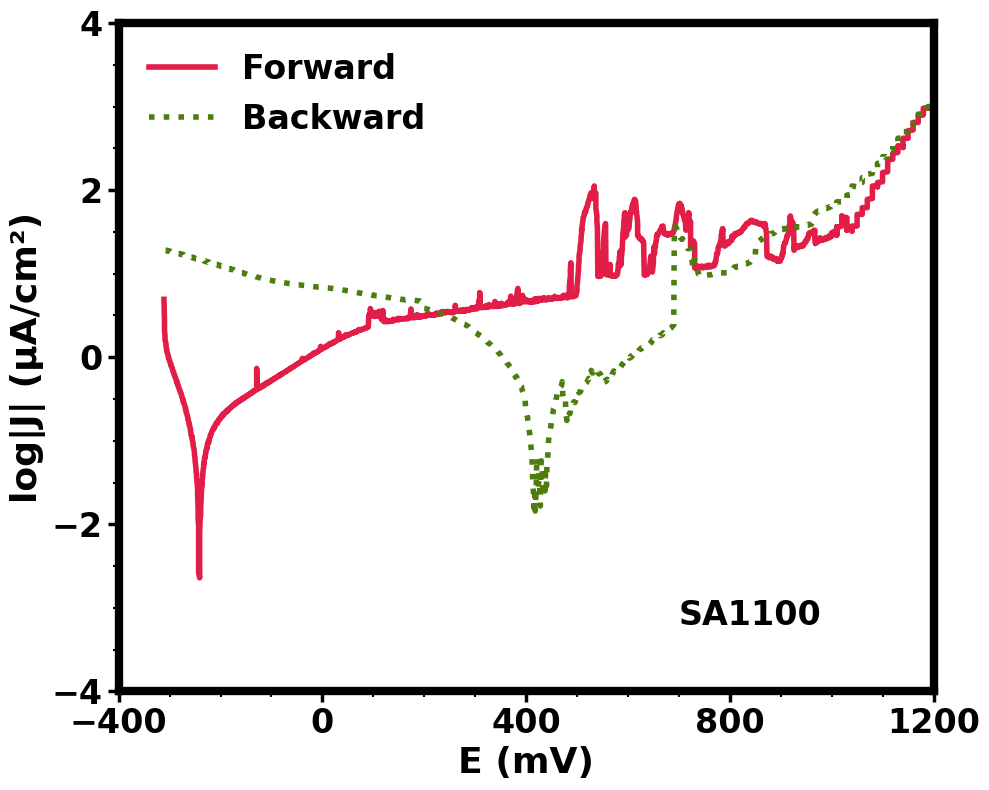

Plot saved as: SA_CPP_plot.png
Plot saved as: SA_CPP_plot.svg


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- File names ---
csv_name = 'SA_CPP.csv'
out_png = 'SA_CPP_plot.png'
out_svg = 'SA_CPP_plot.svg'

# --- Read the CSV ---
df = pd.read_csv(csv_name)

# Clean initial column names
df.columns = [str(c).strip() for c in df.columns]

# Print raw columns
print("Raw columns:")
print(df.columns.tolist())

# --- Fix case where real headers are stored in the first row ---
if len(df) > 0:
    first_row = [str(v).strip() for v in df.iloc[0].tolist()]
    if 'Ewe/mV' in first_row and 'log (|J/µA/cm2|)' in first_row:
        df.columns = first_row
        df = df.iloc[1:].reset_index(drop=True)

# Clean updated column names
df.columns = [str(c).strip() for c in df.columns]

print("Usable columns:")
print(df.columns.tolist())

# --- Actual columns in your uploaded CSV ---
pot_col = 'Ewe/mV'
curr_col = 'log (|J/µA/cm2|)'

# Check that columns exist
if pot_col not in df.columns or curr_col not in df.columns:
    valid_cols = [c for c in df.columns if not str(c).startswith('Unnamed')]
    if len(valid_cols) >= 2:
        pot_col = valid_cols[0]
        curr_col = valid_cols[1]
    else:
        raise KeyError("Could not identify the required potential/current columns.")

print(f"Using columns: {pot_col} | {curr_col}")

# Keep only needed columns
df = df[[pot_col, curr_col]].copy()

# Convert to numeric
df[pot_col] = pd.to_numeric(df[pot_col], errors='coerce')
df[curr_col] = pd.to_numeric(df[curr_col], errors='coerce')
df = df.dropna().reset_index(drop=True)

# --- Remove the first stray point if it causes an artificial jump ---
if len(df) > 1 and abs(df.loc[1, pot_col] - df.loc[0, pot_col]) > 100:
    df = df.iloc[1:].reset_index(drop=True)

# --- Split forward / reverse scan using the maximum potential point ---
split_idx = df[pot_col].idxmax()
forward = df.iloc[:split_idx + 1]
reverse = df.iloc[split_idx + 1:]

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 8))

# Forward scan
ax.plot(
    forward[pot_col],
    forward[curr_col],
    label='Forward',
    linestyle='-',
    linewidth=4,
    color='#E11D48'   # rose pink
)

# Reverse scan
if not reverse.empty:
    ax.plot(
        reverse[pot_col],
        reverse[curr_col],
        label='Backward',
        linestyle=':',
        linewidth=4,
        color='#4D7C0F'   # deep olive
    )

# Labels & limits
ax.set_xlabel('E (mV)', fontsize=26, fontweight='bold')
ax.set_ylabel('log|J| (µA/cm²)', fontsize=26, fontweight='bold')
ax.set_xlim(-400, 1200)
ax.set_ylim(-4, 4)

# Major ticks
ax.set_xticks([-400, 0, 400, 800, 1200])
ax.set_yticks([-4, -2, 0, 2, 4])

# Tick styling
ax.tick_params(axis='both', which='major', direction='out', length=8, width=2.5, labelsize=24)
ax.tick_params(axis='both', which='minor', direction='out', length=4, width=1.5)

for lbl in ax.get_xticklabels() + ax.get_yticklabels():
    lbl.set_fontweight('bold')

# Minor ticks
ax.xaxis.set_minor_locator(ticker.MultipleLocator(100))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))

# Spine thickness
for spine in ax.spines.values():
    spine.set_linewidth(6)

# Legend
leg = ax.legend(fontsize=24, frameon=False)
for line in leg.get_lines():
    line.set_linewidth(4)
for text in leg.get_texts():
    text.set_fontweight('bold')

# Annotation
ax.text(
    700, -3.2, 'SA1100',
    fontsize=24,
    fontweight='bold'
)

plt.grid(False)
plt.tight_layout()

# Save both PNG and SVG
plt.savefig(out_png, dpi=600, bbox_inches='tight')
plt.savefig(out_svg, bbox_inches='tight')

plt.show()

print(f"Plot saved as: {out_png}")
print(f"Plot saved as: {out_svg}")